In [41]:
import os
import sys
import random
import cv2
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join("..")))

In [42]:
from src.preprocessing import preprocess_image
from src.segmentation import segment_products, compute_intensity_mask, compute_saturation_mask, combine_masks
from src.detection import detect_products, draw_detections, crop_products, print_detection_summary, save_detection_outputs

## 1. Load an easy-difficulty checkout image

Point `CHECKOUT_DIR` at the RPC `val2019`/`test2019` checkout images (easy split) after downloading the dataset locally.

In [43]:
CHECKOUT_DIR = "../data/checkout_easy"
OUTPUT_DIR = "../outputs"

sample_files = [f for f in os.listdir(CHECKOUT_DIR) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
sample_path = os.path.join(CHECKOUT_DIR, random.choice(sample_files))
print(sample_path)

../data/checkout_easy\20180829-14-02-50-1747.jpg


## 2. Preprocess (Member 1's module)

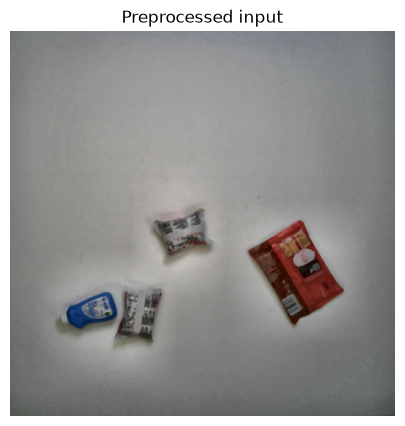

In [44]:
processed = preprocess_image(sample_path)

plt.figure(figsize=(5, 5))
plt.imshow(cv2.cvtColor(processed, cv2.COLOR_BGR2RGB))
plt.title("Preprocessed input")
plt.axis("off")
plt.show()

## 3. Segmentation - inspect the intermediate masks

Shows the intensity mask, the saturation mask, and the combined + cleaned foreground mask side by side, so the segmentation choices can be explained in the demo/viva.

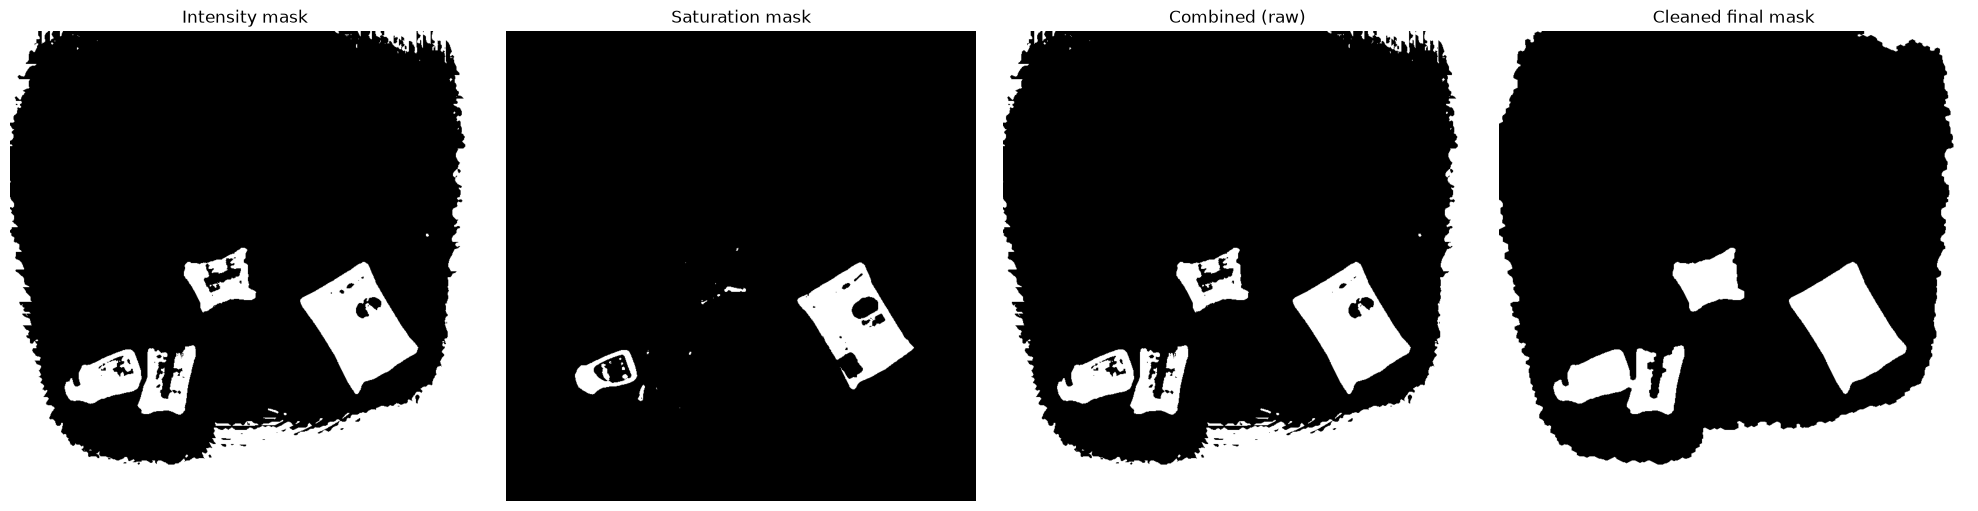

In [45]:
intensity_mask = compute_intensity_mask(processed)
saturation_mask = compute_saturation_mask(processed)
combined_mask = combine_masks(intensity_mask, saturation_mask)
seg_result = segment_products(processed)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
titles = ["Intensity mask", "Saturation mask", "Combined (raw)", "Cleaned final mask"]
masks = [intensity_mask, saturation_mask, combined_mask, seg_result["mask"]]
for ax, title, m in zip(axes, titles, masks):
    ax.imshow(m, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 4. Object detection - bounding boxes + labelled crops

Detected products in 20180829-14-02-50-1747.jpg
-----------------------------------------------
Total products detected: 2
  #01  bbox=(x=1, y=678, w=365, h=121)  area=16610px
  #02  bbox=(x=351, y=573, w=448, h=226)  area=43524px


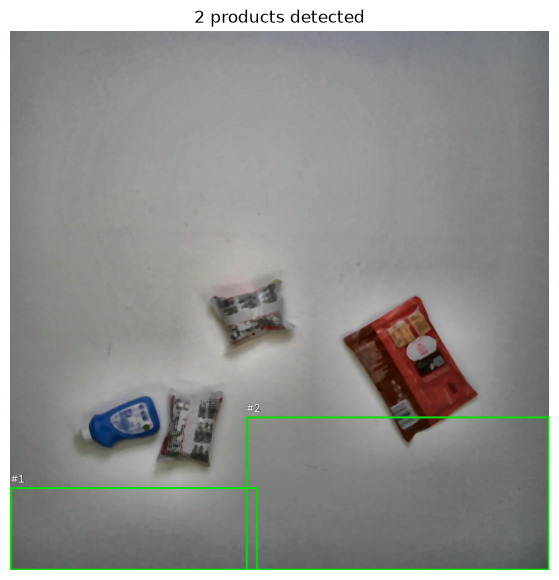

In [46]:
detections = detect_products(processed, seg_result)
print_detection_summary(detections, image_name=os.path.basename(sample_path))

annotated = draw_detections(processed, detections)
plt.figure(figsize=(7, 7))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.title(f"{len(detections)} products detected")
plt.axis("off")
plt.show()

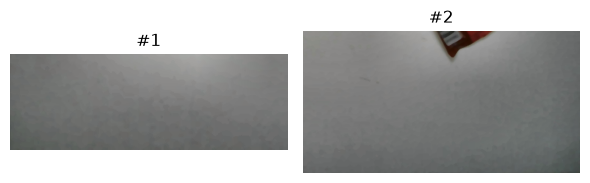

In [47]:
crops = crop_products(processed, detections)

fig, axes = plt.subplots(1, len(crops), figsize=(3 * len(crops), 3))
if len(crops) == 1:
    axes = [axes]
for ax, (det_id, crop) in zip(axes, crops):
    ax.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
    ax.set_title(f"#{det_id}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 5. Save outputs (annotated image + crops for the classification module)

In [48]:
base_name = os.path.splitext(os.path.basename(sample_path))[0]
paths = save_detection_outputs(processed, detections, OUTPUT_DIR, base_name)
paths

{'annotated_path': '../outputs\\annotated_images\\20180829-14-02-50-1747_annotated.jpg',
 'crop_paths': ['../outputs\\crops\\20180829-14-02-50-1747\\20180829-14-02-50-1747_product_01.jpg',
  '../outputs\\crops\\20180829-14-02-50-1747\\20180829-14-02-50-1747_product_02.jpg']}